In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk

#from NN_utils import load_vstate
#from correlations import correlations_vstate

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.devices()

[CudaDevice(id=0)]

In [5]:
from VA_project.lattice.lattice import Chain
from VA_project.model.cm import GeneralNeighborCoupling

fields=[(0., 'X'), (0.5, 'Z'), (0.8, 'Y')]
couplings=[(0.,'ZZ','NN'),(2.,'YY','NN2')]

chain= Chain(6,bc='periodic', order= 'default_1')
ZZYY= GeneralNeighborCoupling(chain, fields, couplings)

In [12]:
nums=[0.2,1.5,5.6]
print("Numeros: %f_%f_%f"%(nums[0],nums[1],nums[2]))
print(f"Numeros: {nums}")

Numeros: 0.200000_1.500000_5.600000
Numeros: [0.2, 1.5, 5.6]


In [2]:
from NN_module.NN_utils import traslations_2D,traslations_2D_scan,traslations_2D_vmap

In [4]:
a=jnp.arange(20)
size=[20,1]
token_size=[2,1]
sub_lat=[size[0]//token_size[0], size[1]//token_size[1]]
# a.reshape((sub_lat[1],token_size[1],sub_lat[0],token_size[0]),
#                   order='C').transpose((0, 2, 1, 3)).reshape(-1,token_size[0]*token_size[1]).squeeze()
#traslations_2D_scan(a,size).reshape(-1,*size)
traslations_2D(a,size, token_size, memory=True)



Array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17],
        [18, 19]],

       [[19,  0],
        [ 1,  2],
        [ 3,  4],
        [ 5,  6],
        [ 7,  8],
        [ 9, 10],
        [11, 12],
        [13, 14],
        [15, 16],
        [17, 18]],

       [[18, 19],
        [ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]],

       [[17, 18],
        [19,  0],
        [ 1,  2],
        [ 3,  4],
        [ 5,  6],
        [ 7,  8],
        [ 9, 10],
        [11, 12],
        [13, 14],
        [15, 16]],

       [[16, 17],
        [18, 19],
        [ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15]],

       [[15, 16],
        [17, 18],
        [19,  0],
        [ 1,  2],
        [ 3,  4],


In [ ]:
import sys
from pathlib import Path
sys.path.append(str("/home/ihuarte/Escritorio/Ivan/ATMOS_VA/VA_project/src"))

from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
from NN_module.sim_utils import (
    load_vstate
)
files=[
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_128_heads_2_blocks_2_ffn_lay_2.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_8_blocks_2_ffn_lay_4.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_2_blocks_2_ffn_lay_4.json"
]

size=[4,4]
strength=0.2
theta=54.
phi=0.
kwargs_lattice={
    'bc':'periodic',
    'order':'default_2'
}

oxa=OxalateJKGamma(
            size, 
            [strength, theta, phi],
            **kwargs_lattice
        )
H = Runner(oxa.cm).build_hamiltonian()
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(eigenstates=True, k=150)
idx=np.argsort(E_ED)
E_ED=E_ED[idx]
x_ED=x_ED.T[idx,:]

In [14]:
i=2
path_artifact= files[i]

with open(path_artifact,'r') as f:
    artifact = json.load(f)

vstate=load_vstate(artifact).to_array()
vstate=np.array(vstate, dtype=np.complex128)


In [15]:
c=np.sum(x_ED.conjugate()*vstate, axis=1)
P=np.abs(c)**2
sum(P)

np.float64(0.135464914189455)

In [16]:
E_best=artifact['results']['E_best']
e=-np.inf; idx=0
while e<E_best:
    e=E_ED[idx]
    idx+=1

idx, E_ED[idx],E_ED[idx-1]

(4, np.float64(-1.5469373598988332), np.float64(-1.5469373598989151))

Text(0.5, 0.8, '$\\Sigma_i\\; P_i = 0.1355$\n$E_1=-1.610$\n$E_{150}=-1.374$\n$E_{sim}=-1.555$')

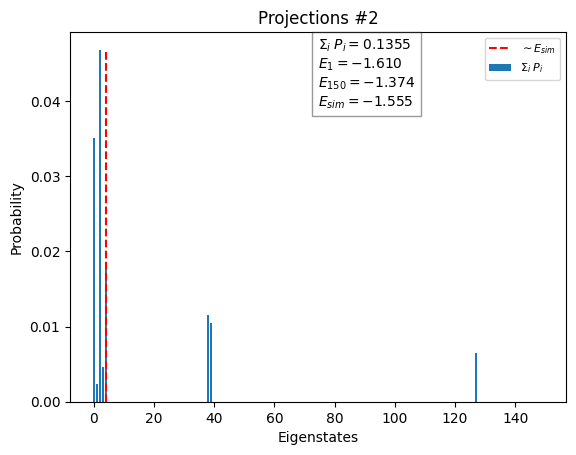

In [18]:
P_sum=sum(P)

_,ax=plt.subplots()
ax.set_title(f"Projections #{i}")
ax.set_xlabel("Eigenstates")
ax.set_ylabel("Probability")
ax.bar(range(len(P)), P, label=r"$\Sigma_i\; P_i$")
ax.vlines(idx, 0,max(P), color='r', ls='--', label=r"$\sim E_{sim}$")
ax.legend(fontsize=8)
ax.text(0.5, 0.8, r"$\Sigma_i\; P_i = %.4f$"%P_sum+"\n"+r"$E_1=%.3f$"%E_ED[0]+"\n"+r"$E_{150}=%.3f$"%(E_ED[-1])+"\n"+r"$E_{sim}=%.3f$"%E_best, transform=ax.transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.4))
#ax.set_yscale('log')

In [12]:
a=False
b=True
not a and b

True

# Learning Rate Scheduler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from NN_module.NN_utils import scheduler_initializer

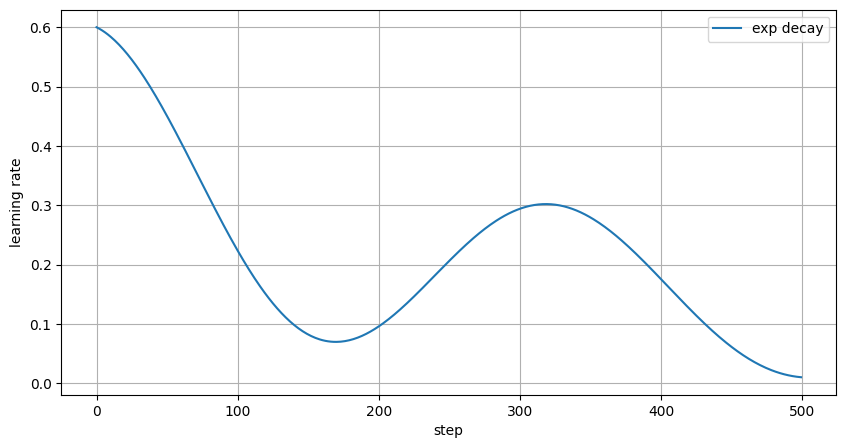

In [21]:

schedule={
    'epochs': 500,
    'cos_exp_scheduler':{
        "lr0":0.6,
        "decay_exp":1.,
        "cosine_cycles":2.,
        "n":0.1,
        "lr_min": 0.01
    }
}

lr_sch=scheduler_initializer('cos_exp_scheduler', schedule)


# recta = lambda x: (lr_min-n)/epochs*x+n
# y_recta=recta(jnp.arange(0,epochs))

y=lr_sch(jnp.arange(0,schedule['epochs']))

_,ax= plt.subplots(1,1,figsize=(10,5))
ax.plot(y, label="exp decay")
#ax.plot(np.arange(epochs),y_recta, ls= '--', color='r')
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
#ax.set_ylim(0, 1.05)
ax.legend()
ax.grid()

In [49]:
21388438632/(1024)**3

19.919535733759403

In [ ]:
import jax.numpy as jnp
import jax
a= jnp.ones((4,4), dtype=complex)/10
b= jnp.ones((4,4) ,dtype=complex)


stack=jnp.array([a,b]).transpose(1,0,2)
z2_sym=jax.nn.logsumexp(
    stack,
    b=jnp.array([1., -1.])[None,:,None],
    axis=1
)
z2_2d_symm=jax.nn.logsumexp(
    z2_sym,
    axis=0
)

In [2]:
from flax.serialization import to_bytes, from_bytes
import msgpack
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/Oxalate_vstate_params_4x4_strength_0.2_theta_90.0_phi_115.2_b_2x1_Demb_64_heads_4_blocks_2_ffn_lay_4.msgpack"

In [4]:
with open(file, "rb") as f:
    bytes_data = f.read()

# Decodifica con msgpack sin un schema de Flax
unpacked = msgpack.unpackb(bytes_data, raw=False)

import pprint
pprint.pprint(unpacked)


{'SpinViT_0': {'SpinViTWorker_0': {'RealSpinViT_0': {'CoreBlock_0': {'LayerNorm_0': {'bias': ExtType(code=1, data=b'\x93\x91@\xa7float64\xc5\x02\x0025#Z(\xdc\x96?2*\x19V\xfb\xe8\xa6?\xac\xe8b@\x1c;\xb5\xbf\xda\x80\xec\xf1\xf6\xaa\x94\xbfc6\xa5\\\xa4_\xbb?\xd8\xe6\xf0s\xf4p\xa8?u\xd4\xd2\x0fM%\xb1?\xe2)\xef\xb149\x8b\xbf\x127\x9d\xb2\xb6\xd0\xae?y\xf1y\x0c,{\xb2?\xe5Z8\x11[f\xa9\xbf3\x05\xe1\xee\xe1<\xa0\xbf\xe0~A\xbb\t*v\xbf\xaf>\x12\xe1>\xbe\xa7\xbfh\xd0\x9d\x8c\xd4\xd1\x7f?\xa3C\x90\x8eib\x9c?\x85\x86\xe0\x00\xf3\xe1\xa0\xbfG\x9aS`\xf2P\xb0\xbf\xafZvA\x16\xee\x9e?I8p6\x05\xed\xa2?IuK\x13r\x04\x8a?\xact%\xcd\x8f\x08\x92?\x1cs\xc1\x9a$\xcc\x8f\xbfU\x0b\xa9\x90\x00(\xb0\xbf3 D&\xc2T\xb1?\x9c"8:\x9ae\x98?\xb3\xaa\xd0\xec\xc1\xa4\xa9?\x7f%\x9f&\x9a\xa7\xbb\xbf\xee\xb5z\xc5\xba\x85\xa8?\xc7N\x95+\xdc=\xa1\xbf\x0bF\xae\xce\xe2\xe6\x8d\xbf\x95\xe9\xe8\xdd`Q\x95\xbfBq\xda"\xba\xb5\x94\xbfM\x14\x98\xeb\n\x0b\xa2?\xfe^\x0c\x8f\xfd=\x8e\xbf\x15\xd3\xa6&\xb0d\x9d\xbfn\xf8\xd4h\x92.\x9e\xbf\x13M\x

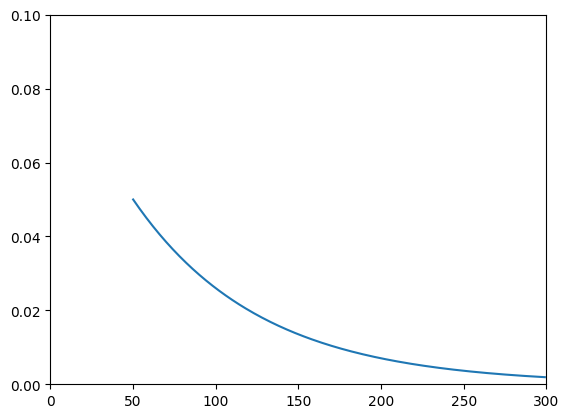

In [28]:
_, ax= plt.subplots()
x=np.arange(50,300)
ax.set_ylim(0,0.1)
ax.set_xlim(0,300)
ax.plot(x,0.05*0.987**(x-50))

In [45]:
import numpy as np
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_xED_4x5_strength_0.2_theta_0_phi_0.txt"
x_ED= np.loadtxt(file, dtype=complex)
x_ED

array([-2.61021185e-05+3.81112898e-05j, -4.67367137e-05+6.82395354e-05j,
       -4.67367137e-05+6.82395354e-05j, ...,
       -4.72456618e-05+6.89826425e-05j, -4.72456618e-05+6.89826425e-05j,
       -2.64158685e-05+3.85693912e-05j], shape=(1048576,))

In [48]:
np.angle(x_ED)

array([2.17131058, 2.17131058, 2.17131058, ..., 2.17131058, 2.17131058,
       2.17131058], shape=(1048576,))

In [3]:
from NN_module.sim_utils import load_vstate
import json
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_results_4x5_strength_0.2_theta_0_phi_0_XZ_-1.0_0.001_J_1.5_alpha_2.5_b_2x1_Demb_32_heads_2_blocks_2_ffn_lay_2.json"

In [4]:
with open(file,'rb') as f:
    conf=json.load(f)

vstate=load_vstate(conf)